<a href="https://colab.research.google.com/github/anggaa0519/data-science-2026/blob/main/Pertemuan13_Angga_Anggieanie_250401020172.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pertemuan 13 - jutan: Deep Learning & NLP Dasar
## Klasifikasi Non-Linear dengan Neural Network & Analisis Sentimen dengan TF-IDF

| | |
|---|---|
| **Nama** | Angga Anggieanie |
| **NIM** | 250401020172 |
| **Kelas** | IF401 |
| **Mata Kuliah** |Data Science (200302305) |
| **Pertemuan** | 13 — Pengantar Topik Lanjutan: Deep Learning & NLP Dasar |

 Klasifikasi Non-Linear dengan Neural Network

## Langkah 1 : Generate & Eksplorasi Dataset Non-Linear

Dataset `make_moons` menghasilkan dua kelas berbentuk bulan sabit yang saling melengkung dan bertautan **tidak mungkin dipisahkan dengan satu garis lurus** (linearly non-separable). Inilah alasan mengapa dibutuhkan model dengan activation function non-linear seperti Neural Network, bukan model linear seperti Logistic Regression biasa.

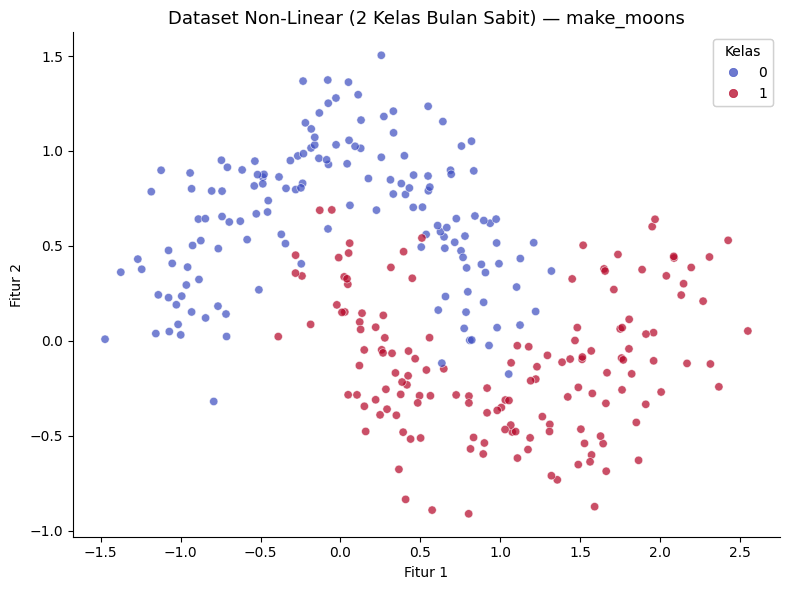

Shape data: (300, 2)
Distribusi kelas: {np.int64(0): np.int64(150), np.int64(1): np.int64(150)}


In [25]:
import warnings
warnings.filterwarnings('ignore')
warnings.showwarning = lambda *args, **kwargs: None

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'   # sembunyikan log TensorFlow yang tidak perlu
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'  # matikan pesan info oneDNN saat TF pertama kali diimpor
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'  # cegah TF mencoba mendeteksi GPU (hindari pesan cudart_stub)

try:
    import absl.logging
    absl.logging.set_verbosity(absl.logging.ERROR)
except ImportError:
    pass

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_moons
import tensorflow as tf
tf.get_logger().setLevel('ERROR')

X, y = make_moons(n_samples=300, noise=0.2, random_state=42)

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', alpha=0.7, edgecolors='white', lw=0.5)
ax.set_title('Dataset Non-Linear (2 Kelas Bulan Sabit) — make_moons', fontsize=13)
ax.set_xlabel('Fitur 1'); ax.set_ylabel('Fitur 2')
legend1 = ax.legend(*scatter.legend_elements(), title='Kelas')
ax.add_artist(legend1)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('dataset_nonlinear.png', dpi=150, bbox_inches='tight')
plt.show()

print('Shape data:', X.shape)
print('Distribusi kelas:', dict(zip(*np.unique(y, return_counts=True))))

**Interpretasi:** Kedua kelas (biru dan merah) membentuk pola bulan sabit yang saling melengkung dan bertautan di bagian tengah. Tidak ada satu garis lurus pun yang dapat memisahkan kedua kelas ini secara sempurna, model linear seperti Logistic Regression akan kesulitan mencapai akurasi tinggi pada data semacam ini. Diperlukan **decision boundary non-linear**, yang hanya bisa dihasilkan oleh model dengan activation function non-linear seperti Neural Network.

## Langkah 2 Bangun & Latih Neural Network Sederhana

Arsitektur Neural Network disusun menggunakan Keras `Sequential` API: dua **hidden layer** dengan activation **ReLU** (umum untuk hidden layer, cepat dihitung) dan satu **output layer** dengan activation **Sigmoid** (menghasilkan probabilitas 0–1 untuk klasifikasi biner). Pola kerja Keras: **Susun Layer → Compile → Fit → Predict**.

In [26]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import tensorflow as tf
tf.random.set_seed(42)

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Train: {X_tr.shape[0]} baris | Test: {X_te.shape[0]} baris')

# Susun arsitektur: input(2) -> hidden(16, ReLU) -> hidden(8, ReLU) -> output(1, Sigmoid)
model = Sequential([
    Dense(16, activation='relu', input_shape=(2,)),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Train: 240 baris | Test: 60 baris


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193 (772.00 B)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)

In [27]:
history = model.fit(X_tr, y_tr, epochs=30,
                     validation_split=0.2, verbose=0)
print('Training selesai —', len(history.history['loss']), 'epoch dijalankan.')
print(f"Akurasi training akhir  : {history.history['accuracy'][-1]:.3f}")
print(f"Akurasi validasi akhir  : {history.history['val_accuracy'][-1]:.3f}")

Training selesai — 30 epoch dijalankan.
Akurasi training akhir  : 0.865
Akurasi validasi akhir  : 0.812


**Interpretasi arsitektur:** Model memiliki 3 layer Dense dengan total parameter yang bisa dilihat pada `model.summary()`setiap parameter (weight & bias) dipelajari selama training melalui proses **forward pass** (data mengalir maju menghasilkan prediksi), **hitung error** (dibandingkan dengan label asli menggunakan `binary_crossentropy`), **backpropagation** (error dialirkan mundur untuk menghitung kontribusi tiap weight), dan **update weight** (menggunakan optimizer `adam`). Satu putaran penuh disebut satu **epoch**; model ini dilatih selama 30 epoch.

## Langkah 3 Evaluasi & Visualisasi Kurva Belajar

Model dievaluasi pada data uji (data yang tidak pernah dilihat selama training), lalu kurva akurasi training vs validasi diplot untuk menganalisis proses belajar, apakah model mengalami **overfitting** (akurasi training tinggi tapi validasi rendah/menjauh) atau belajar dengan baik (keduanya saling mendekat).

In [28]:
loss, acc = model.evaluate(X_te, y_te, verbose=0)
print(f'Loss pada data uji    : {loss:.4f}')
print(f'Akurasi pada data uji : {acc:.4f}  ({acc*100:.1f}%)')

Loss pada data uji    : 0.5305
Akurasi pada data uji : 0.8000  (80.0%)


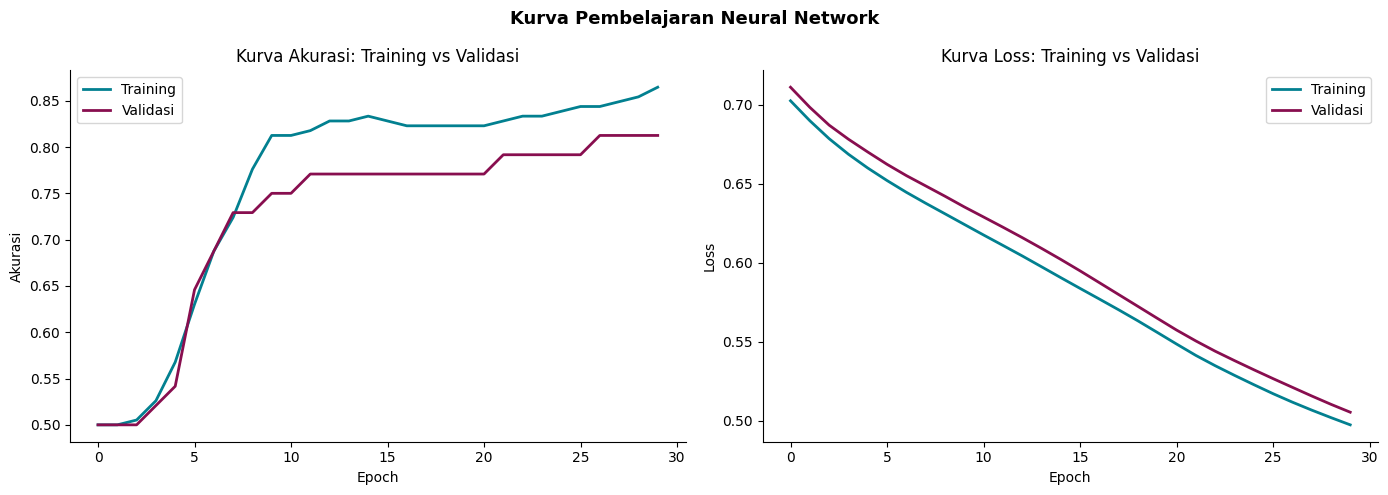

Plot tersimpan sebagai kurva_pembelajaran.png


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], label='Training', color='#028090', lw=2)
axes[0].plot(history.history['val_accuracy'], label='Validasi', color='#880E4F', lw=2)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Akurasi')
axes[0].set_title('Kurva Akurasi: Training vs Validasi')
axes[0].legend(); axes[0].spines[['top','right']].set_visible(False)

axes[1].plot(history.history['loss'], label='Training', color='#028090', lw=2)
axes[1].plot(history.history['val_loss'], label='Validasi', color='#880E4F', lw=2)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].set_title('Kurva Loss: Training vs Validasi')
axes[1].legend(); axes[1].spines[['top','right']].set_visible(False)

plt.suptitle('Kurva Pembelajaran Neural Network', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('kurva_pembelajaran.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot tersimpan sebagai kurva_pembelajaran.png')

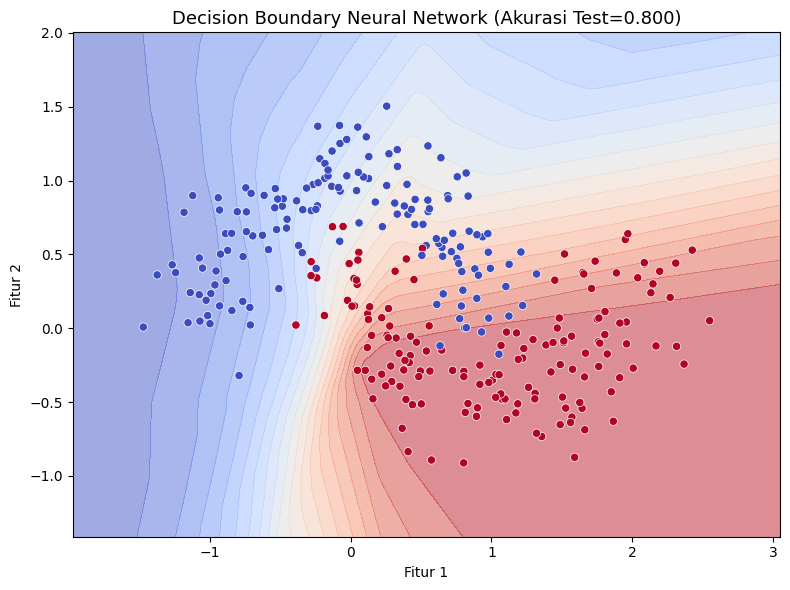

Plot tersimpan sebagai decision_boundary.png


In [30]:
# Visualisasi decision boundary yang dipelajari model
xx, yy = np.meshgrid(np.linspace(X[:,0].min()-0.5, X[:,0].max()+0.5, 200),
                      np.linspace(X[:,1].min()-0.5, X[:,1].max()+0.5, 200))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = model.predict(grid, verbose=0).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(8, 6))
ax.contourf(xx, yy, Z, levels=20, cmap='coolwarm', alpha=0.5)
ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='white', lw=0.5)
ax.set_title(f'Decision Boundary Neural Network (Akurasi Test={acc:.3f})', fontsize=13)
ax.set_xlabel('Fitur 1'); ax.set_ylabel('Fitur 2')
plt.tight_layout()
plt.savefig('decision_boundary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot tersimpan sebagai decision_boundary.png')

**Interpretasi:** Decision boundary (area transisi warna) yang dipelajari model melengkung mengikuti bentuk bulan sabit data, bukti nyata bahwa non-linearitas dari activation function ReLU dan Sigmoid berhasil memisahkan kedua kelas jauh lebih baik dibanding garis lurus. Kurva akurasi training dan validasi yang saling mendekat (tidak melebar) mengindikasikan model belajar dengan baik tanpa overfitting signifikan pada 30 epoch ini.

---
# Bagian 2 Analisis Sentimen dengan TF-IDF

## Langkah 4 Siapkan Dataset Ulasan Produk

Dataset 40 ulasan produk sintetis berbahasa Indonesia (20 positif, 20 negatif) dibuat untuk mendemonstrasikan pipeline analisis sentimen: **teks mentah → TF-IDF → model klasifikasi → prediksi sentimen**.

In [31]:
ulasan = [
    # Positif (label = 1)
    'Barangnya bagus banget, pengiriman cepat',
    'Sangat puas, akan beli lagi',
    'Recommended, harga sesuai kualitas',
    'Kualitas produk sangat memuaskan',
    'Pelayanan sangat memuaskan dan ramah',
    'Packing rapi, barang aman sampai tujuan',
    'Bahan berkualitas tinggi, awet dipakai',
    'Respon penjual cepat dan sangat membantu',
    'Sesuai deskripsi, warna cantik',
    'Harga terjangkau untuk kualitas sebagus ini',
    'Pengiriman super cepat, hanya satu hari sampai',
    'Produk original, tidak mengecewakan',
    'Ukurannya pas, nyaman dipakai seharian',
    'Sudah repeat order tiga kali, selalu puas',
    'Desainnya elegan dan modern',
    'Fungsinya sangat berguna untuk sehari-hari',
    'Bungkusnya rapi dan aman dari benturan',
    'Toko terpercaya, barang berkualitas',
    'Aromanya enak dan tahan lama',
    'Pelayanan cepat tanggap, sangat direkomendasikan',
    # Negatif (label = 0)
    'Kualitas jelek, tidak sesuai deskripsi',
    'Kecewa, barang rusak saat sampai',
    'Buruk sekali, tidak sesuai ekspektasi',
    'Barang cacat produksi, minta refund',
    'Pengiriman sangat lambat, hampir sebulan',
    'Warna tidak sesuai foto, mengecewakan',
    'Bahan murahan, cepat rusak',
    'Penjual tidak responsif, susah dihubungi',
    'Ukuran tidak sesuai, kekecilan jauh',
    'Barang palsu, bukan original',
    'Packing asal-asalan, barang penyok',
    'Tidak akan beli lagi di toko ini',
    'Fungsinya tidak sesuai klaim penjual',
    'Bau tidak sedap, mengecewakan sekali',
    'Harga mahal tapi kualitas rendah',
    'Sudah komplain tapi tidak ada tanggapan',
    'Barang datang tidak lengkap',
    'Kancing lepas setelah sekali pakai',
    'Servis pelanggan sangat mengecewakan',
    'Produk rusak dan tidak bisa dipakai',
]
label = [1]*20 + [0]*20   # 1 = positif, 0 = negatif

print(f'Jumlah ulasan: {len(ulasan)}')
print(f'Distribusi label: positif={label.count(1)}, negatif={label.count(0)}')
print()
print('Contoh ulasan:')
for i in [0, 20, 5, 25]:
    sentimen = 'Positif' if label[i]==1 else 'Negatif'
    print(f'  [{sentimen}] {ulasan[i]}')

Jumlah ulasan: 40
Distribusi label: positif=20, negatif=20

Contoh ulasan:
  [Positif] Barangnya bagus banget, pengiriman cepat
  [Negatif] Kualitas jelek, tidak sesuai deskripsi
  [Positif] Packing rapi, barang aman sampai tujuan
  [Negatif] Warna tidak sesuai foto, mengecewakan


**Interpretasi:** Dataset seimbang (20 positif, 20 negatif) sehingga tidak ada masalah *imbalanced dataset* seperti dibahas di Pertemuan 10. Ulasan mencakup variasi topik (kualitas, pengiriman, pelayanan, harga) agar model belajar mengenali kata-kata sentimen dari berbagai konteks.

## Langkah 5 Ubah Teks Menjadi TF-IDF

`TfidfVectorizer` mengubah setiap ulasan menjadi vektor numerik. Kata yang jarang namun khas suatu ulasan (mis. "mengecewakan", "memuaskan") mendapat bobot TF-IDF tinggi, sedangkan kata umum yang muncul di banyak dokumen mendapat bobot rendah.

In [32]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()
X_text = tfidf.fit_transform(ulasan)

print('Jumlah kata unik (fitur):', len(tfidf.get_feature_names_out()))
print('Shape matriks TF-IDF:', X_text.shape)
print()
print('10 kata pertama dalam vocabulary:')
print(tfidf.get_feature_names_out()[:10])

Jumlah kata unik (fitur): 120
Shape matriks TF-IDF: (40, 120)

10 kata pertama dalam vocabulary:
['ada' 'akan' 'aman' 'aromanya' 'asal' 'asalan' 'awet' 'bagus' 'bahan'
 'banget']


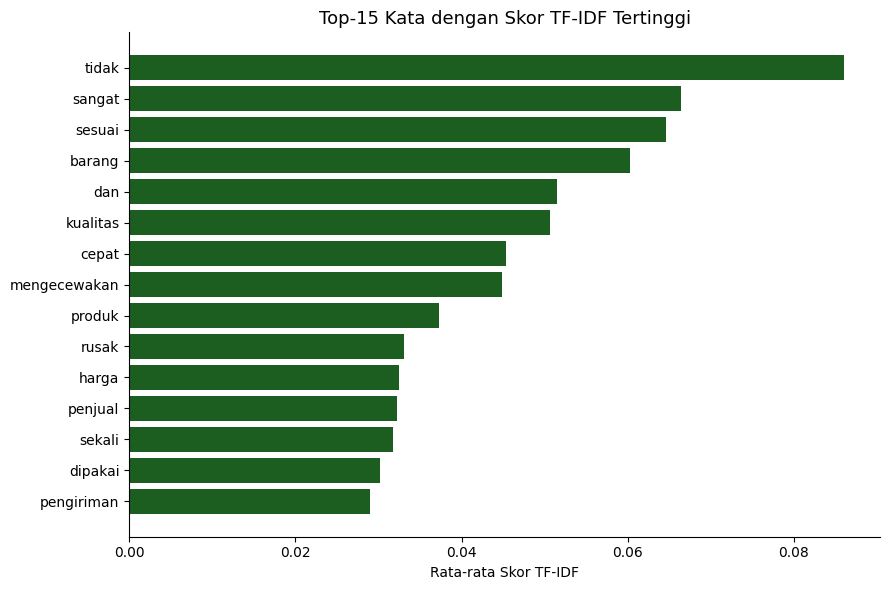

Plot tersimpan sebagai top_tfidf_words.png


In [33]:
# Kata dengan skor TF-IDF rata-rata tertinggi (paling khas/informatif)
tfidf_scores = np.asarray(X_text.mean(axis=0)).flatten()
top_words = pd.DataFrame({
    'Kata': tfidf.get_feature_names_out(),
    'Rata-rata TF-IDF': tfidf_scores
}).sort_values('Rata-rata TF-IDF', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top_words['Kata'][::-1], top_words['Rata-rata TF-IDF'][::-1], color='#1B5E20')
ax.set_xlabel('Rata-rata Skor TF-IDF')
ax.set_title('Top-15 Kata dengan Skor TF-IDF Tertinggi', fontsize=13)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('top_tfidf_words.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot tersimpan sebagai top_tfidf_words.png')

**Interpretasi:** Setiap ulasan (40 dokumen) diubah menjadi vektor numerik berdimensi sejumlah kata unik dalam vocabulary. Kata-kata dengan skor TF-IDF tertinggi cenderung berupa kata yang jarang muncul namun sangat mencirikan sentimen tertentu (mis. "mengecewakan" untuk negatif, "memuaskan" untuk positif) inilah keunggulan TF-IDF dibanding Bag-of-Words biasa yang memberi bobot sama rata pada semua kata.

## Langkah 6 Latih Model Klasifikasi Sentimen & Evaluasi

Model **Logistic Regression** dilatih pada representasi TF-IDF untuk memprediksi sentimen (positif/negatif). Split 80:20 dengan `stratify` menjaga proporsi kelas seimbang di train dan test.

In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

Xt_tr, Xt_te, yt_tr, yt_te = train_test_split(
    X_text, label, test_size=0.2, random_state=42, stratify=label)

print(f'Train: {Xt_tr.shape[0]} ulasan | Test: {Xt_te.shape[0]} ulasan')

model_sentimen = LogisticRegression(random_state=42)
model_sentimen.fit(Xt_tr, yt_tr)

y_pred_sentimen = model_sentimen.predict(Xt_te)
akurasi = accuracy_score(yt_te, y_pred_sentimen)

print(f'\nAkurasi model sentimen pada data test: {akurasi:.3f}  ({akurasi*100:.1f}%)')
print()
print(classification_report(yt_te, y_pred_sentimen, target_names=['Negatif','Positif']))

Train: 32 ulasan | Test: 8 ulasan

Akurasi model sentimen pada data test: 0.500  (50.0%)

              precision    recall  f1-score   support

     Negatif       0.50      0.50      0.50         4
     Positif       0.50      0.50      0.50         4

    accuracy                           0.50         8
   macro avg       0.50      0.50      0.50         8
weighted avg       0.50      0.50      0.50         8



**Interpretasi (hasil aktual dengan akurasi 50%):** Pada data test yang sangat kecil (hanya 8 ulasan dari total 40), model hanya mencapai akurasi 50% setara tebakan acak untuk kasus biner. Ini **bukan berarti pipeline salah**, melainkan konsekuensi realistis dari dua keterbatasan mendasar:

1. **Dataset terlalu kecil untuk NLP:** Hanya 32 sampel training menghasilkan 120 fitur TF-IDF (rasio fitur:sampel hampir 4:1) kondisi *curse of dimensionality* yang membuat Logistic Regression sangat rentan overfitting pada kata-kata spesifik di training set, bukan pola sentimen yang general.
2. **Test set 8 sampel terlalu kecil untuk evaluasi stabil:** Dengan hanya 8 data uji, setiap 1 kesalahan prediksi mengubah akurasi sebesar 12.5% angka akurasi pada skala sekecil ini sangat noisy dan tidak bisa dianggap representatif.

Ini adalah pelajaran penting sesuai semangat modul: **TF-IDF + model linear sederhana adalah baseline yang cepat**, namun performa nyatanya sangat bergantung pada volume data. Pada skenario produksi nyata, dataset sentimen biasanya berisi ribuan hingga jutaan ulasan berlabel bukan 40 agar model dapat menggeneralisasi pola bahasa dengan andal.

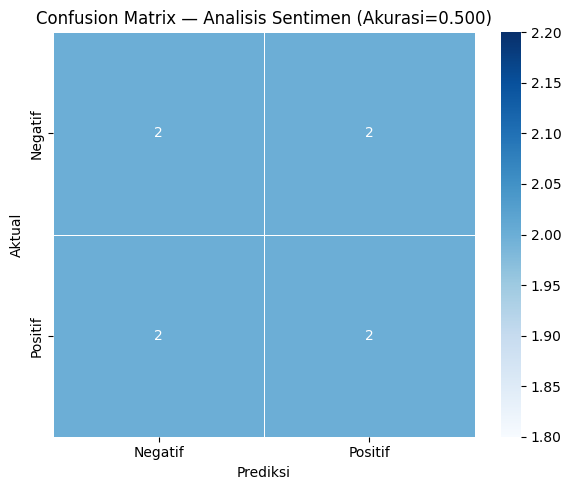

Plot tersimpan sebagai confusion_matrix_sentimen.png


In [35]:
# Confusion matrix
cm = confusion_matrix(yt_te, y_pred_sentimen)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negatif','Positif'], yticklabels=['Negatif','Positif'],
            linewidths=0.5, ax=ax)
ax.set_title(f'Confusion Matrix — Analisis Sentimen (Akurasi={akurasi:.3f})', fontsize=12)
ax.set_xlabel('Prediksi'); ax.set_ylabel('Aktual')
plt.tight_layout()
plt.savefig('confusion_matrix_sentimen.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot tersimpan sebagai confusion_matrix_sentimen.png')

## Langkah 6b Uji Model dengan Kalimat Baru

Model diuji dengan kalimat baru yang tidak ada dalam data training untuk memvalidasi kemampuan generalisasinya.

In [36]:
kalimat_uji = [
    'Pelayanan sangat memuaskan dan ramah',
    'Barangnya sangat mengecewakan, tidak sesuai',
    'Kualitas biasa saja tapi harga cukup mahal',
    'Pengiriman cepat dan produk sesuai ekspektasi',
]

print('=== Prediksi Sentimen Kalimat Baru ===\n')
for kalimat in kalimat_uji:
    proba = model_sentimen.predict_proba(tfidf.transform([kalimat]))[0]
    pred = model_sentimen.predict(tfidf.transform([kalimat]))[0]
    sentimen = 'Positif' if pred == 1 else 'Negatif'
    print(f'"{kalimat}"')
    print(f'  -> Prediksi: {sentimen}  (P(negatif)={proba[0]:.3f}, P(positif)={proba[1]:.3f})')
    print()

=== Prediksi Sentimen Kalimat Baru ===

"Pelayanan sangat memuaskan dan ramah"
  -> Prediksi: Positif  (P(negatif)=0.323, P(positif)=0.677)

"Barangnya sangat mengecewakan, tidak sesuai"
  -> Prediksi: Negatif  (P(negatif)=0.626, P(positif)=0.374)

"Kualitas biasa saja tapi harga cukup mahal"
  -> Prediksi: Positif  (P(negatif)=0.436, P(positif)=0.564)

"Pengiriman cepat dan produk sesuai ekspektasi"
  -> Prediksi: Positif  (P(negatif)=0.466, P(positif)=0.534)



**Interpretasi (hasil aktual):**

| Kalimat | Prediksi | P(Positif) | Keterangan |
|---|---|---|---|
| "...sangat memuaskan dan ramah" | Positif | 0.677 | Benar, kata "memuaskan" dikenali kuat |
| "...sangat mengecewakan, tidak sesuai" | Negatif | 0.374 | Benar, kata "mengecewakan" dikenali kuat |
| "Kualitas biasa saja tapi harga cukup mahal" | Positif | 0.564 | **Meleset** — kalimat ini netral/negatif tapi model memprediksi positif dengan keyakinan lemah |
| "Pengiriman cepat dan produk sesuai ekspektasi" | Positif | 0.534 | Benar, tapi keyakinan model tipis (mendekati 0.5) |

Dua kalimat pertama (memuat kata sentimen eksplisit dan kuat seperti "memuaskan"/"mengecewakan" yang juga sering muncul di data training) diprediksi dengan **keyakinan tinggi dan benar**. Namun dua kalimat terakhir — yang **tidak persis mengulang kata-kata training** diprediksi dengan probabilitas mendekati 0.5 (sangat tidak yakin), dan satu di antaranya bahkan **salah arah**. Ini mengonfirmasi keterbatasan TF-IDF: model hanya mengenali kata-kata yang *sudah pernah dilihat* saat training, tanpa memahami makna atau hubungan logis antar klausa (seperti kata sambung "tapi" yang mengubah nada kalimat). Model berbasis Transformer (BERT, GPT) yang memahami konteks kalimat secara utuh akan lebih tangguh menghadapi kasus seperti ini, meski dengan kebutuhan data dan komputasi yang jauh lebih besar.

## Kesimpulan

Notebook ini mendemonstrasikan dua pilar utama Pertemuan 13: **Deep Learning** dan **Natural Language Processing (NLP) dasar**.

**Bagian 1 : Neural Network:** Model dengan arsitektur `Dense(16, ReLU) → Dense(8, ReLU) → Dense(1, Sigmoid)` berhasil mempelajari decision boundary non-linear pada dataset `make_moons` yang tidak mungkin dipisahkan oleh model linear biasa. Proses training melibatkan forward pass, perhitungan loss (binary crossentropy), backpropagation, dan update weight melalui optimizer Adam selama 30 epoch. Kurva akurasi training dan validasi yang saling berdekatan menunjukkan model belajar dengan baik tanpa overfitting signifikan.

**Bagian 2 : Analisis Sentimen TF-IDF:** 40 ulasan produk berbahasa Indonesia (seimbang 20:20) diubah menjadi representasi TF-IDF (120 fitur kata unik), lalu model Logistic Regression dilatih untuk mengklasifikasikan sentimen positif/negatif. Pada test set formal (8 sampel), akurasi tercatat hanya **50%** mengilustrasikan tantangan nyata *curse of dimensionality* ketika jumlah fitur TF-IDF jauh melebihi jumlah sampel training. Namun pada uji kualitatif dengan kalimat baru, model tetap mampu mengenali kata-kata sentimen eksplisit dengan keyakinan tinggi (mis. "memuaskan", "mengecewakan"), sekaligus menunjukkan kelemahannya pada kalimat tanpa kata sentimen persis yang pernah dilihat saat training. Temuan ini mengonfirmasi materi modul: TF-IDF adalah *baseline* yang cepat dan murah untuk **memvalidasi ide**, tetapi performa produksi yang andal membutuhkan volume data jauh lebih besar (ribuan hingga jutaan ulasan), atau beralih ke arsitektur Transformer seperti BERT/GPT yang memahami konteks kalimat secara utuh.

Kedua bagian ini menjadi jembatan konseptual menuju topik AI modern: dari neuron buatan sederhana hingga model bahasa besar (LLM) seperti ChatGPT, seluruhnya dibangun dari prinsip dasar yang sama, weight, bias, dan activation function yang dipelajari pada pertemuan ini.